# 55 Sale & Rent Models — XGBoost definitivo

Modelos XGBoost definitivos para **sale** y **rent**, construidos automáticamente a partir de los resultados exportados por los notebooks individuales.

| Modelo | Fuente | Notebook |
|--------|--------|----------|
| Sale   | `data/model_results/params_sale.json` | `53_boost_sale_optuna` |
| Rent   | `data/model_results/params_rent.json` | `53_boost_rent` |

**Flujo:** ejecuta primero el notebook individual (53_boost_*) → exporta el JSON → ejecuta este notebook. Cualquier cambio en features, hiperparámetros o limpieza en los notebooks individuales se propaga aquí automáticamente.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PARAMS_DIR   = PROJECT_ROOT / "data" / "model_results"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Params dir: {PARAMS_DIR}")

Proyecto: /Users/sitomachucas/Documents/BezanillaSL
Params dir: /Users/sitomachucas/Documents/BezanillaSL/data/model_results


## 1. Cargar parámetros desde JSON

In [2]:
# ── Cargar configuraciones exportadas por los notebooks individuales ───────────
sale_cfg = json.loads((PARAMS_DIR / "params_sale.json").read_text(encoding="utf-8"))
rent_cfg = json.loads((PARAMS_DIR / "params_rent.json").read_text(encoding="utf-8"))

# ── Rutas de datos ────────────────────────────────────────────────────────────
SALE_PATH = PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv"
RENT_PATH = PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv"

# ── Constantes compartidas (de los JSONs) ─────────────────────────────────────
RANDOM_STATE = sale_cfg["random_state"]
TEST_SIZE    = sale_cfg["test_size"]
CV_FOLDS     = sale_cfg["cv_folds"]

# ── Config SALE ───────────────────────────────────────────────────────────────
SALE_TARGET_COL     = sale_cfg["target_col"]
SALE_IQR_FACTOR     = sale_cfg["iqr_factor"]
SALE_MIN_MUNI_OBS   = sale_cfg["min_muni_obs"]
SALE_PRECIO_M2_MIN  = sale_cfg["precio_m2_min"]
SALE_BASE_FEATURES  = sale_cfg["base_features"]
XGB_PARAMS_SALE     = {**sale_cfg["xgb_params"],
                        "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0}

# ── Config RENT ───────────────────────────────────────────────────────────────
RENT_TARGET_COL            = rent_cfg["target_col"]
RENT_IQR_FACTOR            = rent_cfg["iqr_factor"]
RENT_MIN_MUNI_OBS          = rent_cfg["min_muni_obs"]
RENT_PRECIO_M2_VACACIONAL  = rent_cfg["precio_m2_vacacional_umbral"]
RENT_PRECIO_M2_MIN         = rent_cfg["precio_m2_min_umbral"]
RENT_BASE_FEATURES         = rent_cfg["base_features"]
XGB_PARAMS_RENT            = {**rent_cfg["xgb_params"],
                               "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0}

print("Configuración cargada:")
print(f"  Sale  [{sale_cfg['notebook']}]  trial #{sale_cfg['optuna_best_trial']}  "
      f"CV-RMSE={sale_cfg['optuna_cv_rmse']}  Test R\u00b2={sale_cfg['test_r2']}")
print(f"  Rent  [{rent_cfg['notebook']}]  trial #{rent_cfg['optuna_best_trial']}  "
      f"CV-RMSE={rent_cfg['optuna_cv_rmse']}  Test R\u00b2={rent_cfg['test_r2']}")
print(f"\n  Sale features ({len(SALE_BASE_FEATURES)}): {SALE_BASE_FEATURES[:3]} ...")
print(f"  Rent features ({len(RENT_BASE_FEATURES)}): {RENT_BASE_FEATURES[:3]} ...")

Configuración cargada:
  Sale  [53_boost_sale_optuna]  trial #76  CV-RMSE=0.23347  Test R²=0.8531
  Rent  [53_boost_rent]  trial #97  CV-RMSE=0.14622  Test R²=0.6179

  Sale features (21): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos'] ...
  Rent features (19): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos'] ...


## 2. Funciones auxiliares

In [3]:
def build_X(df: pd.DataFrame, base_features: list, min_muni_obs: int) -> tuple:
    """Construye X con base_features + municipio_* OHE agrupando raros."""
    df2 = df.copy()
    base = [f for f in base_features if f in df2.columns]
    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < min_muni_obs].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []
    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X, all_feats


def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse = mean_squared_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(float(mse), 5)],
        "RMSE": [round(float(np.sqrt(mse)), 5)],
        "MAE":  [round(float(mean_absolute_error(y_real, y_pred)), 5)],
        "R2":   [round(float(r2_score(y_real, y_pred)), 5)],
        "MAPE": [round(float(mean_absolute_percentage_error(y_real, y_pred)), 5)],
    })


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)"); ax.set_ylabel("Predicho (log_precio)")
    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo"); ax.set_ylabel("Frecuencia")
    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")
    plt.tight_layout(); plt.show()


def plot_feature_importance(importances, feature_names, title, top_n=20):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title); ax.set_xlabel("Importancia")
    plt.tight_layout(); plt.show()
    return fi


print("Funciones cargadas.")

Funciones cargadas.


## 3. Modelo SALE

DATASET: SALE  [53_boost_sale_optuna  trial #76]
Filas originales: 2694
  IQR×1.5 eliminados: 0 (0.0%)
  Suelo precio_m2 < 1000 €/m² eliminados: 151 (5.6%)
Filas tras limpieza: 2543
Features (52): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'muni

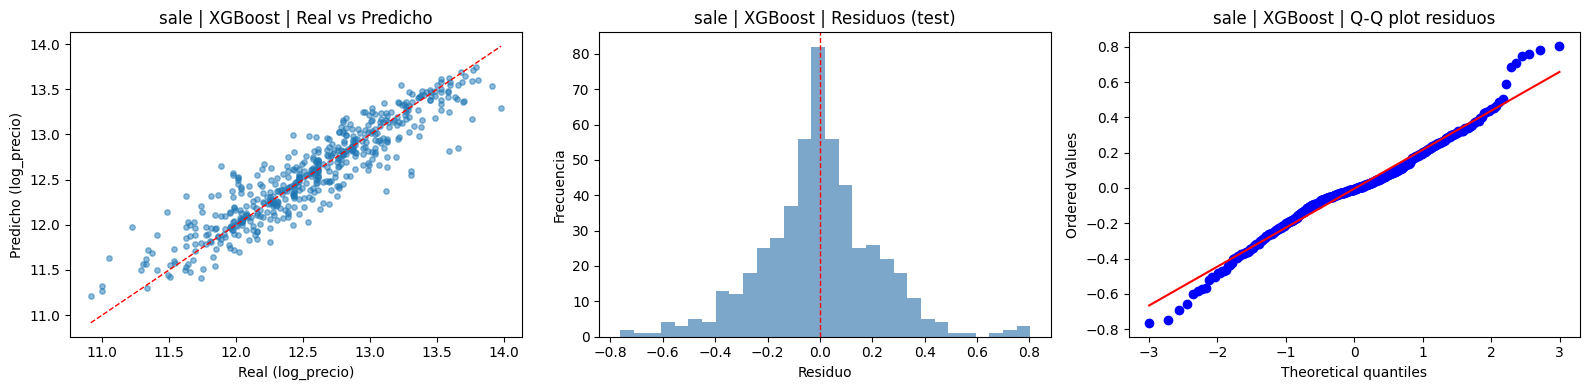

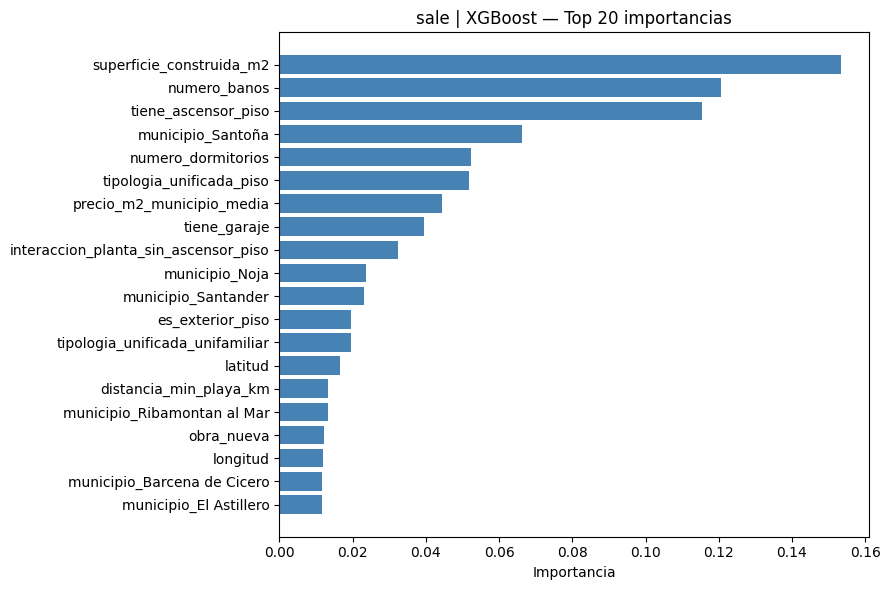

,feature,importance
0,superficie_construida_m2,0.153270
2,numero_banos,0.120529
7,tiene_ascensor_piso,0.115420
43,municipio_Santoña,0.066357
1,numero_dormitorios,0.052209
19,tipologia_unificada_piso,0.051666
13,precio_m2_municipio_media,0.044408
8,tiene_garaje,0.039557
16,interaccion_planta_sin_ascensor_piso,0.032321
35,municipio_Noja,0.023757


In [4]:
print("=" * 90)
print(f"DATASET: SALE  [{sale_cfg['notebook']}  trial #{sale_cfg['optuna_best_trial']}]")
print("=" * 90)

# ── Carga ─────────────────────────────────────────────────────────────────────
df_sale = pd.read_csv(SALE_PATH)
df_sale = df_sale[df_sale[SALE_TARGET_COL].notna()].copy()
print(f"Filas originales: {len(df_sale)}")

# ── Limpieza: IQR\u00d71.5 sobre log_precio ──────────────────────────────────────
q1, q3 = df_sale[SALE_TARGET_COL].quantile([0.25, 0.75])
iqr = q3 - q1
mask_iqr = df_sale[SALE_TARGET_COL].between(q1 - SALE_IQR_FACTOR * iqr, q3 + SALE_IQR_FACTOR * iqr)
print(f"  IQR\u00d7{SALE_IQR_FACTOR} eliminados: {(~mask_iqr).sum()} ({(~mask_iqr).mean()*100:.1f}%)")
df_sale = df_sale[mask_iqr].copy()

# ── Limpieza: suelo precio_m2 ─────────────────────────────────────────────────
mask_m2 = df_sale["precio_m2"] >= SALE_PRECIO_M2_MIN
print(f"  Suelo precio_m2 < {SALE_PRECIO_M2_MIN} \u20ac/m\u00b2 eliminados: {(~mask_m2).sum()} ({(~mask_m2).mean()*100:.1f}%)")
df_sale = df_sale[mask_m2].copy()
print(f"Filas tras limpieza: {len(df_sale)}")

# ── Features ──────────────────────────────────────────────────────────────────
X_sale, feats_sale = build_X(df_sale, SALE_BASE_FEATURES, SALE_MIN_MUNI_OBS)
y_sale = df_sale[SALE_TARGET_COL].values
print(f"Features ({X_sale.shape[1]}): {feats_sale}")

# ── Split 80/20 ───────────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_sale, y_sale, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_sale = XGBRegressor(**XGB_PARAMS_SALE)
model_sale.fit(X_tr, y_tr)

# ── CV-RMSE ───────────────────────────────────────────────────────────────────
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
sale_cv_rmse = float(-cross_val_score(
    XGBRegressor(**XGB_PARAMS_SALE), X_tr, y_tr,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
).mean())

# ── M\u00e9tricas ──────────────────────────────────────────────────────────────────
m_tr = get_metrics(y_tr, model_sale.predict(X_tr))
m_te = get_metrics(y_te, model_sale.predict(X_te))
summary = pd.concat([
    m_tr.assign(split="train"),
    pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(sale_cv_rmse, 5)],
                  "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_te.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
print(f"\n{summary.to_string(index=False)}")
delta_r2 = float(m_tr["R2"].iloc[0]) - float(m_te["R2"].iloc[0])
ratio    = float(m_te["RMSE"].iloc[0]) / max(float(m_tr["RMSE"].iloc[0]), 1e-9)
print(f"\n  Sobreajuste \u2192 ratio RMSE test/train: {ratio:.4f} | delta R\u00b2: {delta_r2:.4f}")

plot_diagnostics(y_te, model_sale.predict(X_te), "sale | XGBoost")
plot_feature_importance(model_sale.feature_importances_, feats_sale,
                        "sale | XGBoost \u2014 Top 20 importancias")

## 4. Modelo RENT

DATASET: RENT  [53_boost_rent  trial #97]
Filas originales: 754
  Vacacionales eliminados (precio_m2 > 18.0): 61 (8.1%)
  Anomías baratas eliminadas (precio_m2 < 6.0): 12 (1.7%)
  IQR×1.5 eliminados: 19 (2.8%)
Filas tras limpieza: 662
Features (27): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El Astillero', 'municipio_Piélagos', 'municipio_Santander', 'municipio_Torrelavega', 'municipio_otro', 'municipio_otros']
Train: 529 | Test: 133

split     MSE    RMSE     MAE      R2    MAPE
train

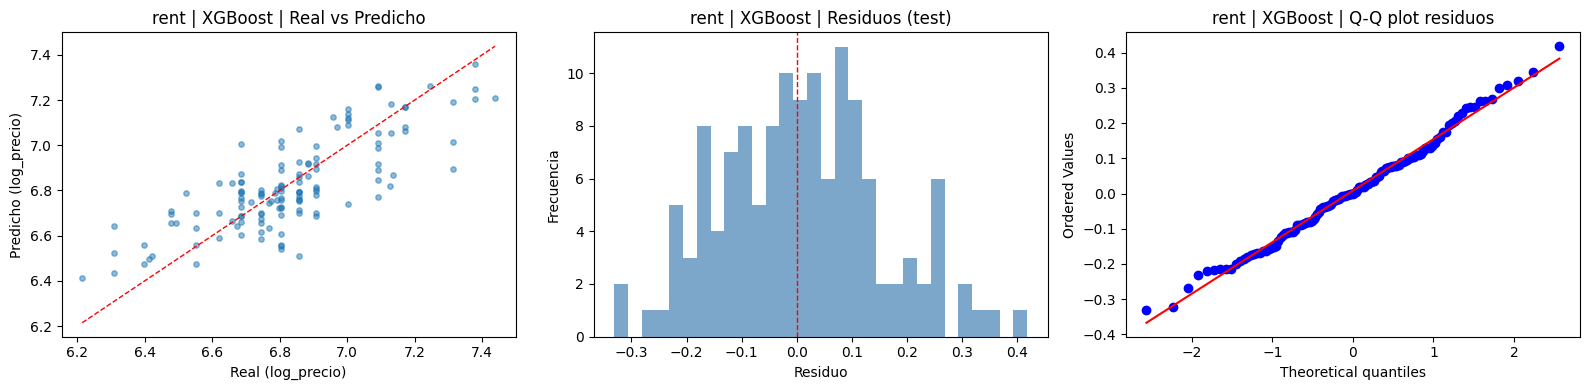

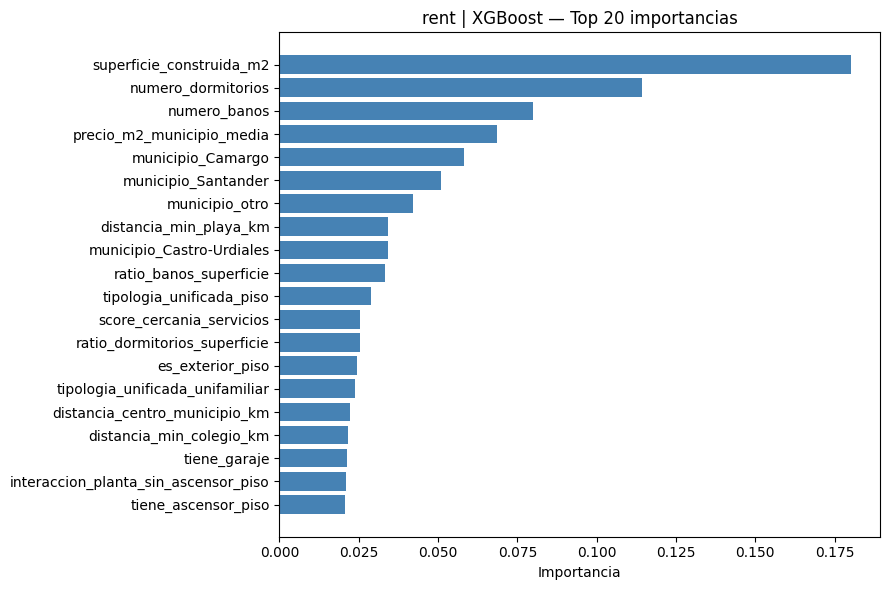

,feature,importance
0,superficie_construida_m2,0.180315
1,numero_dormitorios,0.114159
2,numero_banos,0.079953
11,precio_m2_municipio_media,0.068444
19,municipio_Camargo,0.058170
23,municipio_Santander,0.050953
25,municipio_otro,0.042223
8,distancia_min_playa_km,0.034337
20,municipio_Castro-Urdiales,0.034190
13,ratio_banos_superficie,0.033210


In [5]:
print("=" * 90)
print(f"DATASET: RENT  [{rent_cfg['notebook']}  trial #{rent_cfg['optuna_best_trial']}]")
print("=" * 90)

# ── Carga ─────────────────────────────────────────────────────────────────────
df_rent = pd.read_csv(RENT_PATH)
df_rent = df_rent[df_rent[RENT_TARGET_COL].notna() & df_rent["precio_m2"].notna()].copy()
print(f"Filas originales: {len(df_rent)}")

# ── Limpieza: vacacionales ────────────────────────────────────────────────────
mask_vac = df_rent["precio_m2"] <= RENT_PRECIO_M2_VACACIONAL
print(f"  Vacacionales eliminados (precio_m2 > {RENT_PRECIO_M2_VACACIONAL}): {(~mask_vac).sum()} ({(~mask_vac).mean()*100:.1f}%)")
df_rent = df_rent[mask_vac].copy()

# ── Limpieza: anom\u00edas baratas ──────────────────────────────────────────────────
mask_min = df_rent["precio_m2"] >= RENT_PRECIO_M2_MIN
print(f"  Anom\u00edas baratas eliminadas (precio_m2 < {RENT_PRECIO_M2_MIN}): {(~mask_min).sum()} ({(~mask_min).mean()*100:.1f}%)")
df_rent = df_rent[mask_min].copy()

# ── Limpieza: IQR\u00d71.5 sobre log_precio ──────────────────────────────────────────
q1, q3 = df_rent[RENT_TARGET_COL].quantile([0.25, 0.75])
iqr = q3 - q1
mask_iqr = df_rent[RENT_TARGET_COL].between(q1 - RENT_IQR_FACTOR * iqr, q3 + RENT_IQR_FACTOR * iqr)
print(f"  IQR\u00d7{RENT_IQR_FACTOR} eliminados: {(~mask_iqr).sum()} ({(~mask_iqr).mean()*100:.1f}%)")
df_rent = df_rent[mask_iqr].copy()
print(f"Filas tras limpieza: {len(df_rent)}")

# ── Features ──────────────────────────────────────────────────────────────────
X_rent, feats_rent = build_X(df_rent, RENT_BASE_FEATURES, RENT_MIN_MUNI_OBS)
y_rent = df_rent[RENT_TARGET_COL].values
print(f"Features ({X_rent.shape[1]}): {feats_rent}")

# ── Split 80/20 ───────────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_rent, y_rent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_rent = XGBRegressor(**XGB_PARAMS_RENT)
model_rent.fit(X_tr, y_tr)

# ── CV-RMSE ───────────────────────────────────────────────────────────────────
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rent_cv_rmse = float(-cross_val_score(
    XGBRegressor(**XGB_PARAMS_RENT), X_tr, y_tr,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
).mean())

# ── M\u00e9tricas ──────────────────────────────────────────────────────────────────
m_tr = get_metrics(y_tr, model_rent.predict(X_tr))
m_te = get_metrics(y_te, model_rent.predict(X_te))
summary = pd.concat([
    m_tr.assign(split="train"),
    pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(rent_cv_rmse, 5)],
                  "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_te.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
print(f"\n{summary.to_string(index=False)}")
delta_r2 = float(m_tr["R2"].iloc[0]) - float(m_te["R2"].iloc[0])
ratio    = float(m_te["RMSE"].iloc[0]) / max(float(m_tr["RMSE"].iloc[0]), 1e-9)
print(f"\n  Sobreajuste \u2192 ratio RMSE test/train: {ratio:.4f} | delta R\u00b2: {delta_r2:.4f}")

plot_diagnostics(y_te, model_rent.predict(X_te), "rent | XGBoost")
plot_feature_importance(model_rent.feature_importances_, feats_rent,
                        "rent | XGBoost \u2014 Top 20 importancias")